<a href="https://colab.research.google.com/github/liminalvoid/cv-project/blob/main/sem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 3. Линейная классификация текстов в sklearn: Logistic Regression

## Импорт необходимых библиотек

In [121]:
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from datasets import load_dataset


RANDOM_SEED = 52

np.random.seed(RANDOM_SEED)

# Увеличение размера графиков
plt.rcParams["figure.dpi"] = 140

## Исходные данные

Исходные данные – сообщения на форуме «Двач» с указанным эмоциональным интентом.

In [122]:
ru_emotion_dvach_ds = load_dataset("Kostya165/ru_emotion_dvach")
ru_emotion_dvach_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 59061
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2507
    })
})

Выбранные классы – `aggression` и `sarcasm`.

In [123]:
selected_classes = ["aggression", "sarcasm"]

ds_filtered = ru_emotion_dvach_ds.filter(
    lambda example: (
        example["label"] in selected_classes and
        # Также отфильтруем пустые строки
        example["text"]
    )
)
labels_count = Counter(ds_filtered["train"]["label"])

print(f"Количество документов: {len(ds_filtered["train"]) + len(ds_filtered["validation"])}\n")

print("Баланс классов\n")
{print(f"Класс `{name}`: {count}") for name, count in labels_count.items()};

Количество документов: 24515

Баланс классов

Класс `sarcasm`: 11693
Класс `aggression`: 11820


Данные в исходном датасете разбиты на тренировочные и валидационные. Далее разобъем валидационную выборку на тестовую и валидационную в соотношении 1 к 1.

In [124]:
df_train = ds_filtered["train"].to_pandas()
X_train, y_train = np.array(df_train["text"], dtype=object), np.array(df_train["label"])

df_validation = ds_filtered["validation"].to_pandas()
X_val, X_test, y_val, y_test = train_test_split(
    df_validation["text"],
    df_validation["label"],
    test_size=0.5,
    stratify=df_validation["label"],
    random_state=RANDOM_SEED,
)

[
    print(f"{label}: {size}")
    for label, size in zip(
        ["train", "validation", "test"],
        [len(X_train), len(X_val), len(X_test)]
    )
];

train: 23513
validation: 501
test: 501


## Базовый векторайзер (TF-IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro-F1. Подбор гиперпараметров (eta, tol, max_iter). Предобработка для "мешка слов"

### Логистическая регрессия и подбор степени регуляризации

Используем пайплайн из TF-IDF векторайзера и логистической регрессии и подберем оптимальный параметр степени регуляризации $\alpha$.

### Поиск гиперпараметров

Произведем подбор гиперпараметров с помощью `GridSearchCV`.

In [125]:
# Команда для отключения текущей клетки
#%%script false --no-raise-error
# Убрать вывод для текущей клетки
%%capture

parameters = {
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1],
    "clf__eta0": [1e-4, 1e-3, 1e-2, 0.1, 1],
    "clf__tol": [1e-4, 1e-3, 1e-2],
    "clf__max_iter": [100, 500, 1000, 2000],
}

pipeline = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            learning_rate="constant",
            random_state=RANDOM_SEED,
        ),
    ),
])

clf = GridSearchCV(pipeline, parameters, n_jobs=-1)
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Ниже приведены наилучшие параметры, полученные после подбора.

In [127]:
clf.best_params_

{'clf__alpha': 1e-06,
 'clf__eta0': 0.01,
 'clf__max_iter': 500,
 'clf__tol': 0.0001}

Оценка на тренировочном и валидационном датасетах для модели с полученными гиперпараметрами.

In [129]:
y_test_pred = clf.predict(X_test)
y_val_pred = clf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"), "\n")

print(
    "Отчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique(),
    ),
)

Validation accuracy: 0.9441117764471058
Validation macro-F1: 0.9441097724230254 

Test accuracy: 0.9321357285429142
Test macro-F1: 0.9321138211382114 

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.92      0.95      0.93       250
     sarcasm       0.95      0.91      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



Построим матрицу несоответствий.

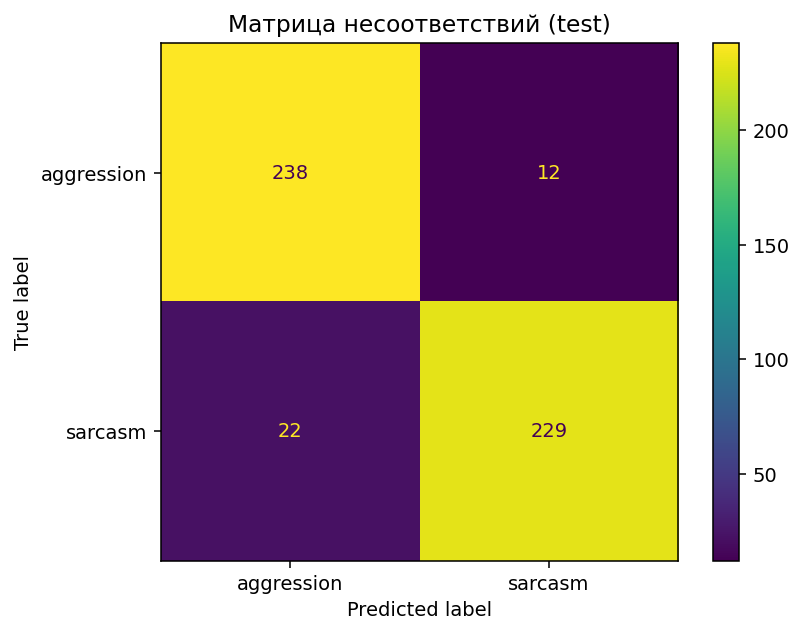

In [131]:
disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

## Линейный SVM (подбор C)